In [1]:
import sys
import os
import time
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt

# Add root directory to sys.path so python finds eigenflow
sys.path.append(os.path.abspath("../"))

from eigenflow.datasets import FeynmanDatasetGenerator
from eigenflow.layers import MLP, KAN
from eigenflow.utils import plot_loss_comparison

In [2]:
# Generate Relativistic Time Dilation dataset
key = jax.random.PRNGKey(42)
dataset_key, init_key = jax.random.split(key)

generator = FeynmanDatasetGenerator("I.15.3t")
X_raw, y_raw, metadata = generator.generate(
    key=dataset_key,
    num_samples=10000,
    noise_level=0.01,
    noise_type="gaussian",
    input_scaling="minmax_11", # KAN splines prefer [-1, 1] range
    target_scaling="raw"
)

split = int(0.8 * len(X_raw))
X_train, X_test = X_raw[:split], X_raw[split:]
y_train, y_test = y_raw[:split], y_raw[split:]
print(f"Generated {len(X_raw)} samples. Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Generated 10000 samples. Train shape: (8000, 3), Test shape: (2000, 3)


In [4]:
# 1. MLP Performance Evaluation
mlp_key, init_key = jax.random.split(init_key)
mlp = MLP(layer_sizes=[3, 64, 64, 1], squeeze=True)
mlp_params = mlp.init(mlp_key)

optimizer_mlp = optax.adam(3e-3)
opt_state_mlp = optimizer_mlp.init(mlp_params)

def mlp_loss(p, x, y):
    return jnp.mean((mlp(p, x) - y) ** 2)

@jax.jit
def mlp_step(p, state, x, y):
    loss, grads = jax.value_and_grad(mlp_loss)(p, x, y)
    updates, state = optimizer_mlp.update(grads, state, p)
    p = optax.apply_updates(p, updates)
    return p, state, loss

# Measure JIT Compilation Time
print("Compiling MLP train step...")
t0 = time.time()
_, _, _ = mlp_step(mlp_params, opt_state_mlp, X_train[:10], y_train[:10])
mlp_compile_time = time.time() - t0
print(f"MLP Compilation Time: {mlp_compile_time:.4f} seconds")

# Training Loop
mlp_losses = []
epochs = 2000
print(f"Training MLP for {epochs} epochs...")
t0 = time.time()
for epoch in range(epochs):
    mlp_params, opt_state_mlp, loss = mlp_step(mlp_params, opt_state_mlp, X_train, y_train)
    mlp_losses.append(float(loss))
mlp_train_time = time.time() - t0

final_mlp_test_loss = mlp_loss(mlp_params, X_test, y_test)
print(f"MLP Training Time: {mlp_train_time:.4f} seconds ({mlp_train_time/epochs*1000:.4f} ms/epoch)")
print(f"MLP Final Test Loss: {final_mlp_test_loss:.6f}")

Compiling MLP train step...
MLP Compilation Time: 0.1047 seconds
Training MLP for 2000 epochs...
MLP Training Time: 1.7330 seconds (0.8665 ms/epoch)
MLP Final Test Loss: 0.018381


In [5]:
# 2. KAN Performance Evaluation
kan_key, init_key = jax.random.split(init_key)
kan = KAN(layer_sizes=[3, 16, 16, 1], grid_size=5, spline_order=3)
kan_params, kan_grids = kan.init(kan_key)

optimizer_kan = optax.adam(5e-3)
opt_state_kan = optimizer_kan.init(kan_params)

def kan_loss(p, g, x, y):
    return jnp.mean((kan(p, g, x) - y) ** 2)

@jax.jit
def kan_step(p, g, state, x, y):
    loss, grads = jax.value_and_grad(kan_loss, argnums=0)(p, g, x, y)
    updates, state = optimizer_kan.update(grads, state, p)
    p = optax.apply_updates(p, updates)
    return p, state, loss

# Measure JIT Compilation Time
print("Compiling KAN train step...")
t0 = time.time()
_, _, _ = kan_step(kan_params, kan_grids, opt_state_kan, X_train[:10], y_train[:10])
kan_compile_time = time.time() - t0
print(f"KAN Compilation Time: {kan_compile_time:.4f} seconds")

# Training Loop
kan_losses = []
print(f"Training KAN for {epochs} epochs...")
t0 = time.time()
for epoch in range(epochs):
    kan_params, opt_state_kan, loss = kan_step(kan_params, kan_grids, opt_state_kan, X_train, y_train)
    kan_losses.append(float(loss))
kan_train_time = time.time() - t0

final_kan_test_loss = kan_loss(kan_params, kan_grids, X_test, y_test)
print(f"KAN Training Time: {kan_train_time:.4f} seconds ({kan_train_time/epochs*1000:.4f} ms/epoch)")
print(f"KAN Final Test Loss: {final_kan_test_loss:.6f}")

Compiling KAN train step...
KAN Compilation Time: 0.2232 seconds
Training KAN for 2000 epochs...
KAN Training Time: 10.1694 seconds (5.0847 ms/epoch)
KAN Final Test Loss: 0.001051



--- Performance Comparison Summary ---
MLP: Compilation = 0.1047s | Training = 1.7330s | Test Loss = 0.018381
KAN: Compilation = 0.2232s | Training = 10.1694s | Test Loss = 0.001051


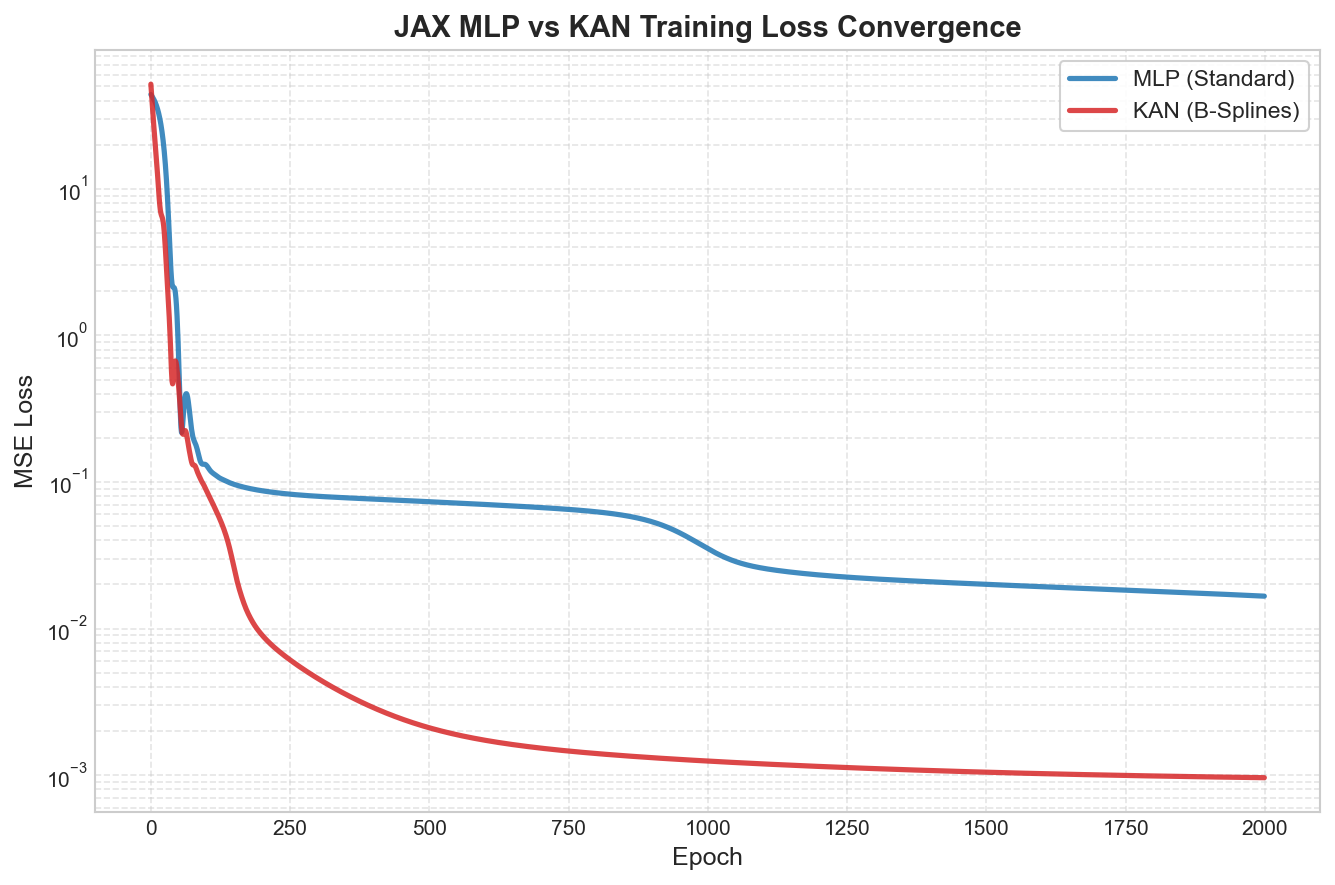

In [ ]:
# 3. Compare and Plot Convergence
print("\n--- Performance Comparison Summary ---")
print(f"MLP: Compilation = {mlp_compile_time:.4f}s | Training = {mlp_train_time:.4f}s | Test Loss = {final_mlp_test_loss:.6f}")
print(f"KAN: Compilation = {kan_compile_time:.4f}s | Training = {kan_train_time:.4f}s | Test Loss = {final_kan_test_loss:.6f}")

plot_loss_comparison(
    loss_dict={"MLP (Standard)": mlp_losses, "KAN (B-Splines)": kan_losses},
    title="JAX MLP vs KAN Training Loss Convergence"
)